In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# BLOCK 1: DATA ACQUISITION & PREPROCESSING

ticker = "^GSPC"  # S&P 500 Index
data = yf.download(ticker, start="1998-01-01", end="2026-04-18", progress=False)

# Calculate daily log-returns (multiplied by 100 for percentage scale)
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1)) * 100
data = data.dropna()
returns = data['Log_Returns']

# Train-Test Split (80% In-Sample, 20% Out-of-Sample)
split_idx = int(len(returns) * 0.8)
train_returns = returns.iloc[:split_idx]
test_returns = returns.iloc[split_idx:]

print(f"In-Sample Period: {train_returns.index[0].date()} to {train_returns.index[-1].date()}")
print(f"Out-of-Sample Period: {test_returns.index[0].date()} to {test_returns.index[-1].date()}\n")

In-Sample Period: 1998-01-05 to 2020-08-17
Out-of-Sample Period: 2020-08-18 to 2026-04-17



ADF Statistic: -13.8656
p-value: 6.6060e-26
Result: Strong evidence against H0. The series is stationary.



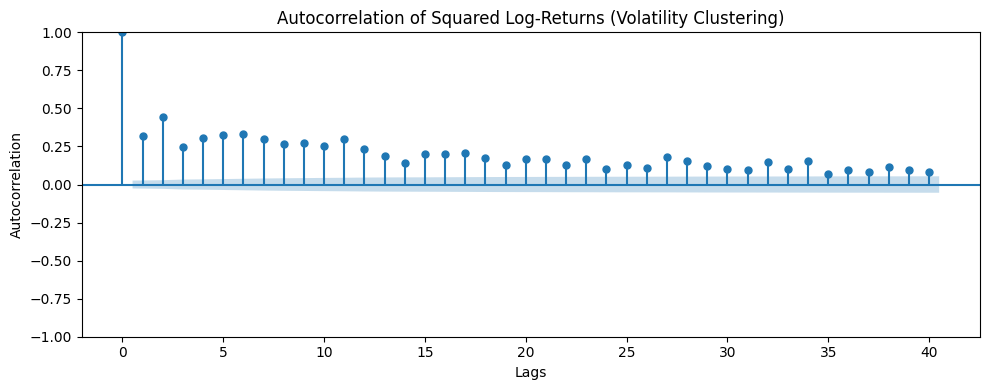

In [3]:
# BLOCK 2: DIAGNOSTICS & STATIONARITY

# 1. Augmented Dickey-Fuller (ADF) Test for Stationarity
adf_result = adfuller(train_returns)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4e}")
if adf_result[1] < 0.05:
    print("Result: Strong evidence against H0. The series is stationary.\n")

# 2. Volatility Clustering Check (ACF of squared returns)
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(train_returns**2, ax=ax, lags=40, alpha=0.05)
ax.set_title("Autocorrelation of Squared Log-Returns (Volatility Clustering)")
ax.set_xlabel("Lags")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig("acf_squared_returns.png")
plt.show()

                        Markov Switching Model Results                        
Dep. Variable:            Log_Returns   No. Observations:                 5692
Model:               MarkovRegression   Log Likelihood               -8177.722
Date:                Mon, 20 Apr 2026   AIC                          16367.444
Time:                        14:15:12   BIC                          16407.325
Sample:                             0   HQIC                         16381.330
                               - 5692                                         
Covariance Type:               robust                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0777      0.013      6.180      0.000       0.053       0.102
sigma2         0.4995      0.033     15.365      0.0

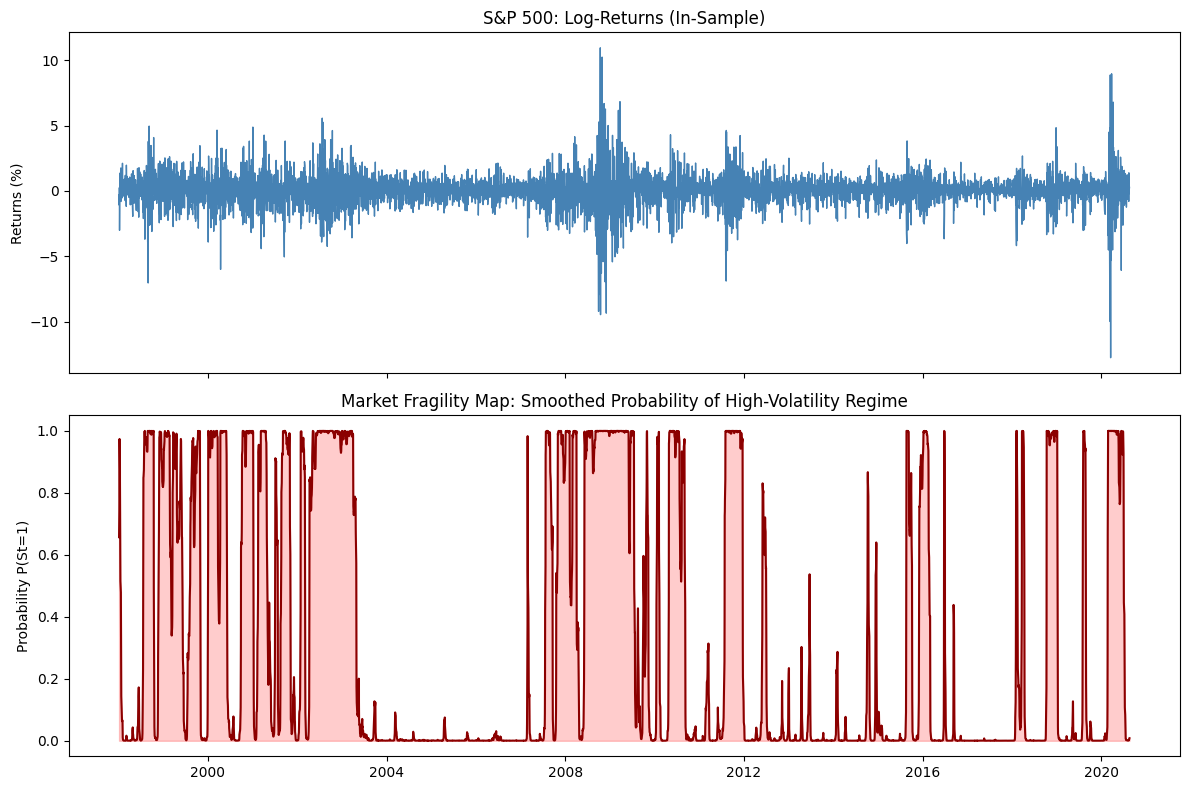

In [9]:
# BLOCK 3: HAMILTON FILTER ESTIMATION

# Estimate Markov Regression with switching variance
# We use QML (Quasi-Maximum Likelihood) implicitly via the approx covariance matrix
ms_model = sm.tsa.MarkovRegression(
    train_returns,
    k_regimes=2,
    trend='c',
    switching_variance=True
)
res_ms = ms_model.fit(cov_type='robust')
print(res_ms.summary())

# Extract Smoothed Probabilities for the High-Volatility Regime (Crisis)
# Assuming Regime 1 is the high variance state based on the output
smoothed_probs_train = res_ms.smoothed_marginal_probabilities[1]

# Returns vs Regime Probabilities (The "Fragility Map")
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(train_returns.index, train_returns, color='steelblue', lw=1)
axes[0].set_title('S&P 500: Log-Returns (In-Sample)')
axes[0].set_ylabel('Returns (%)')

axes[1].plot(smoothed_probs_train.index, smoothed_probs_train, color='darkred', lw=1.5)
axes[1].fill_between(smoothed_probs_train.index, 0, smoothed_probs_train, color='red', alpha=0.2)
axes[1].set_title('Market Fragility Map: Smoothed Probability of High-Volatility Regime')
axes[1].set_ylabel('Probability P(St=1)')

plt.tight_layout()
plt.savefig("insample_fragility_map.png")
plt.show()

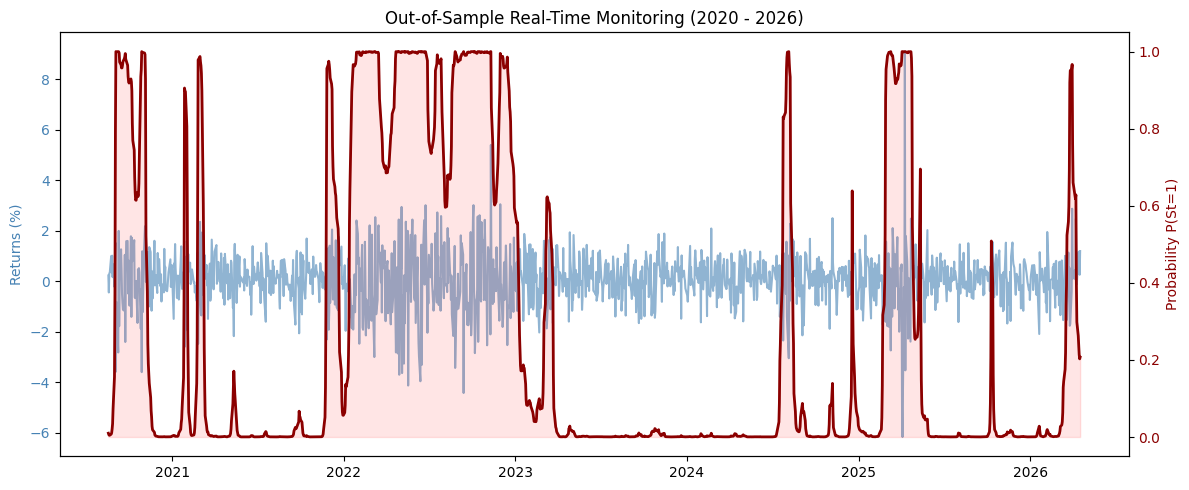

In [12]:
# BLOCK 4: OUT-OF-SAMPLE REAL-TIME MONITORING

# Apply the estimated parameters to new, unseen data (No re-estimation)
test_model_ms = sm.tsa.MarkovRegression(
    test_returns,
    k_regimes=2,
    trend='c',
    switching_variance=True
)
res_test_ms = test_model_ms.smooth(res_ms.params)

# Extract OOS Probabilities
filtered_probs_test = res_test_ms.filtered_marginal_probabilities[1]

# Plot OOS performance (Returns + Probabilities overlay)
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(test_returns.index, test_returns, color='steelblue', alpha=0.6, label='Returns (OOS)')
ax1.set_ylabel('Returns (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(smoothed_probs_test.index, smoothed_probs_test, color='darkred', lw=2, label='Crisis Probability')
ax2.fill_between(smoothed_probs_test.index, 0, smoothed_probs_test, color='red', alpha=0.1)
ax2.set_ylabel('Probability P(St=1)', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('Out-of-Sample Real-Time Monitoring (2020 - 2026)')
fig.tight_layout()
plt.savefig("oos_monitoring.png")
plt.show()

In [13]:
# BLOCK 5: MODEL COMPARISON: HAMILTON VS ARMA

# 1. Fit ARMA(1,1) Benchmark Model
arma_model = ARIMA(train_returns, order=(1, 0, 1))
res_arma = arma_model.fit()

# 2. Generate OOS Predictions
# MS Prediction: Weighted average of regime means based on predicted probabilities
forecast_ms = res_test_ms.predict()
# ARMA Prediction: Constant parameter projection
forecast_arma = res_arma.forecast(steps=len(test_returns))

# 3. Calculate Error Metrics
rmse_ms = np.sqrt(mean_squared_error(test_returns, forecast_ms))
mae_ms = mean_absolute_error(test_returns, forecast_ms)

rmse_arma = np.sqrt(mean_squared_error(test_returns, forecast_arma))
mae_arma = mean_absolute_error(test_returns, forecast_arma)

print(f"Hamilton Filter (MS) -> RMSE: {rmse_ms:.4f} | MAE: {mae_ms:.4f}")
print(f"ARMA(1,1) Benchmark  -> RMSE: {rmse_arma:.4f} | MAE: {mae_arma:.4f}")

improvement = (1 - (rmse_ms / rmse_arma)) * 100
print(f"RMSE Improvement over benchmark: {improvement:.2f}%")

Hamilton Filter (MS) -> RMSE: 1.0608 | MAE: 0.7569
ARMA(1,1) Benchmark  -> RMSE: 1.0647 | MAE: 0.7623
RMSE Improvement over benchmark: 0.37%
